# Proyecto ML — Modelado y validación (Entrega 2)

**Objetivo de E2:** comparar 2–3 familias de modelos para clasificación de macro-género musical bajo un esquema de validación **sin leakage**, y seleccionar el modelo ganador con criterios estadísticos (no solo "el mayor accuracy").

**Conexión con E1:**
- Reutilizamos el mapeo de sub-géneros → macro-géneros (ver `src/genre_mapping.py`, justificación original en E1 sección 2).
- Reutilizamos la limpieza de datos (deduplicación por `track_id`, filtro de outliers básicos).
- **Corrección crítica:** detectamos en E2 que el split aleatorio de E1 producía *leakage por artista* (un mismo artista con tracks en train y test). E1 fue re-ejecutado con el split corregido; aquí usamos el mismo esquema desde el inicio. Ver `report/reporte_e2.md` sección "Corrección metodológica".

**Familias de modelos comparadas:**
1. **Lineal:** `LogisticRegression` multinomial (continuidad con E1).
2. **Tree ensemble — bagging:** `RandomForestClassifier`.
3. **Tree ensemble — boosting:** `HistGradientBoostingClassifier` (built-in sklearn, sin dependencias adicionales).

**Esquema de validación:**
- **Outer holdout (~20%):** `StratifiedGroupKFold(n_splits=5)`, primer fold como test. Agrupado por `artists` y estratificado por `macro_genre`. **No se toca hasta el final.**
- **Inner CV (sobre el 80% train):** `StratifiedGroupKFold(n_splits=5)` para producir distribución de scores por modelo → base para tests estadísticos.

**Secciones:**
0. Setup
1. Carga, limpieza y mapeo (reproducción de E1)
2. Estrategia de validación sin leakage
3. Pipeline de preprocesamiento
4. Familias de modelos a comparar
5. Cross-validation y captura de scores por fold *(pendiente — Slice 4)*
6. Comparación estadística entre modelos *(pendiente — Slice 5)*
7. Evaluación final en test holdout *(pendiente — Slice 5)*
8. Conclusiones *(pendiente — Slice 6)*

## 0. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.genre_mapping import (
    CATEGORICAL_FEATURES,
    GENRE_MAPPING,
    MACRO_GENRES,
    NUMERIC_FEATURES,
)

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "spotify_tracks.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH:    {DATA_PATH}")
print(f"Existe CSV?:  {DATA_PATH.exists()}")
print(f"Features numéricas:    {NUMERIC_FEATURES}")
print(f"Features categóricas:  {CATEGORICAL_FEATURES}")
print(f"Macro-géneros target: {MACRO_GENRES}")

PROJECT_ROOT: D:\Programming\EAFIT\ML\Proyecto_ML
DATA_PATH:    D:\Programming\EAFIT\ML\Proyecto_ML\data\raw\spotify_tracks.csv
Existe CSV?:  True
Features numéricas:    ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
Features categóricas:  ['key', 'mode', 'time_signature', 'explicit']
Macro-géneros target: ['ambient', 'asian-pop', 'classical', 'electronic', 'folk', 'hip-hop', 'jazz', 'kids-comedy', 'latin', 'metal', 'other', 'pop', 'reggae', 'rock', 'soul-funk', 'world']


## 1. Carga, limpieza y mapeo de géneros

Reproducimos el flujo de E1 para tener un punto de partida consistente:

1. Cargar `spotify_tracks.csv`.
2. Eliminar columnas índice residuales (`Unnamed: 0`).
3. Deduplicar por `track_id` (la misma canción puede aparecer en múltiples sub-géneros).
4. Filtrar outliers básicos: `duration_ms < 30 s` o `tempo == 0`.
5. Aplicar `GENRE_MAPPING` y rellenar con `"other"` los sub-géneros no mapeados.

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

n_raw = len(df)
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)
n_dedup = len(df)

mask_bad = (df["duration_ms"] < 30_000) | (df["tempo"] == 0)
df = df.loc[~mask_bad].reset_index(drop=True)
n_clean = len(df)

df["macro_genre"] = df["track_genre"].map(GENRE_MAPPING).fillna("other")

print(f"Filas crudas:                   {n_raw:,}")
print(f"Tras deduplicar por track_id:   {n_dedup:,}  (-{n_raw - n_dedup:,})")
print(f"Tras filtrar outliers básicos:  {n_clean:,}  (-{n_dedup - n_clean:,})")
print(f"\nDistribución de macro-géneros:")
print(df["macro_genre"].value_counts())

Filas crudas:                   114,000
Tras deduplicar por track_id:   89,741  (-24,259)
Tras filtrar outliers básicos:  89,571  (-170)

Distribución de macro-géneros:
macro_genre
electronic     14890
rock            9661
latin           9176
world           8774
metal           7426
folk            7113
asian-pop       6270
kids-comedy     4847
ambient         4798
pop             3561
soul-funk       3448
reggae          2874
classical       2508
hip-hop         2235
other           1467
jazz             523
Name: count, dtype: int64


## 2. Estrategia de validación sin leakage

**Problema detectado en E1:** un split aleatorio (`train_test_split` estratificado solo por clase) permitía que canciones de un mismo artista cayeran en train y test. Con 11.265 artistas que tienen ≥2 tracks (top: George Jones con 260, The Beatles con 149), el modelo aprendía la *firma sonora del artista* en lugar del género real, inflando las métricas reportadas.

**Solución adoptada (E2):**

- **Outer holdout (≈20% test, ≈80% train):** `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` tomando el **primer fold** como test. Esto garantiza:
    - Estratificación por `macro_genre` (clases desbalanceadas).
    - Grupos por `artists`: ningún artista aparece en train y test simultáneamente.
    - Test set **intocado** hasta la evaluación final.
- **Inner CV (sobre el train):** `StratifiedGroupKFold(n_splits=5)` para producir 5 estimaciones de cada métrica por modelo. Sin esto no se pueden hacer tests estadísticos pareados.

**Métrica primaria:** `macro_f1` (clases desbalanceadas).  
**Secundarias:** `accuracy`, `balanced_accuracy`, `top_3_accuracy`.

In [3]:
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "macro_genre"
GROUP = "artists"

X = df[FEATURES].copy()
y = df[TARGET].copy()
groups = df[GROUP].copy()

# Outer holdout: primer fold de un StratifiedGroupKFold(n_splits=5) → ~20% test
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(outer_cv.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

print(f"Train: {X_train.shape}  |  artistas: {groups_train.nunique():,}")
print(f"Test:  {X_test.shape}  |  artistas: {groups_test.nunique():,}")
overlap = len(set(groups_train) & set(groups_test))
print(f"Solapamiento de artistas train ∩ test: {overlap}  (debe ser 0)")

print(f"\nDistribución de clases en train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print(f"\nDistribución de clases en test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: (71657, 14)  |  artistas: 25,100
Test:  (17914, 14)  |  artistas: 6,286
Solapamiento de artistas train ∩ test: 0  (debe ser 0)

Distribución de clases en train (%):
macro_genre
electronic     16.62
rock           10.79
latin          10.24
world           9.80
metal           8.29
folk            7.94
asian-pop       7.00
kids-comedy     5.41
ambient         5.36
pop             3.97
soul-funk       3.85
reggae          3.21
classical       2.80
hip-hop         2.50
other           1.64
jazz            0.59
Name: proportion, dtype: float64

Distribución de clases en test (%):
macro_genre
electronic     16.62
rock           10.78
latin          10.24
world           9.80
metal           8.29
folk            7.94
asian-pop       7.00
kids-comedy     5.41
ambient         5.36
pop             3.98
soul-funk       3.85
reggae          3.21
classical       2.80
hip-hop         2.50
other           1.64
jazz            0.57
Name: proportion, dtype: float64


### 2.1 CV interno para comparar modelos

Definimos un `StratifiedGroupKFold` con 5 folds sobre el `train` para que cada modelo produzca **5 scores** por métrica. Estos scores son la base de:

- Intervalos de confianza por bootstrap.
- Paired t-test / Wilcoxon signed-rank entre pares de modelos.
- Tamaño de efecto (Cohen's d).
- Corrección por comparaciones múltiples (Bonferroni).

In [4]:
inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Verificación rápida: los 5 folds del inner CV tampoco deben tener leakage de artista.
for fold, (tr_idx, va_idx) in enumerate(
    inner_cv.split(X_train, y_train, groups=groups_train), 1
):
    g_tr = set(groups_train.iloc[tr_idx])
    g_va = set(groups_train.iloc[va_idx])
    overlap = len(g_tr & g_va)
    print(
        f"Fold {fold}: train={len(tr_idx):>6,}  val={len(va_idx):>5,}  "
        f"artistas val={len(g_va):>5,}  solapamiento={overlap}"
    )

Fold 1: train=57,337  val=14,320  artistas val=5,031  solapamiento=0
Fold 2: train=57,307  val=14,350  artistas val=5,002  solapamiento=0
Fold 3: train=57,337  val=14,320  artistas val=5,027  solapamiento=0
Fold 4: train=57,335  val=14,322  artistas val=5,039  solapamiento=0
Fold 5: train=57,312  val=14,345  artistas val=5,001  solapamiento=0


### 2.2 Verificación experimental del impacto del leakage

Las celdas anteriores demuestran *estructuralmente* que el split agrupado no tiene solapamiento de artistas. Pero **¿cuánto cambia el desempeño del modelo cuando hay leakage vs cuando no?** Esta celda corre el mismo modelo (Logistic Regression) sobre dos splits distintos y compara:

- **Split A — aleatorio estratificado por clase** (lo que hicimos originalmente en E1, *con* leakage por artista).
- **Split B — `StratifiedGroupKFold` agrupado por artista** (la corrección de E2, *sin* leakage).

La diferencia de métricas entre A y B **es el "premium" del leakage**: cuánta sobrestimación de desempeño produce la fuga. Esto es el chequeo definitivo que cualquiera puede reproducir abriendo el notebook.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Preprocessor temporal para esta verificación (idéntico al de la sección 3).
_pre_check = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)


def _quick_eval(Xtr, Xte, ytr, yte) -> dict:
    pipe = Pipeline(
        [
            ("pre", _pre_check),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    )
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    return {
        "macro_f1": f1_score(yte, pred, average="macro"),
        "accuracy": accuracy_score(yte, pred),
    }


# Split A: aleatorio estratificado por clase (replica el flujo de E1 original).
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
overlap_random = len(set(groups.iloc[Xa_tr.index]) & set(groups.iloc[Xa_te.index]))

# Split B: ya lo tenemos en memoria (X_train / X_test).
overlap_grouped = len(set(groups_train) & set(groups_test))

print("=== Solapamiento de artistas entre train y test ===")
print(f"  Split aleatorio (E1 original):   {overlap_random:>6,} artistas  --> LEAKAGE")
print(f"  Split agrupado  (E2 corregido):  {overlap_grouped:>6,} artistas  --> sin leakage")

print()
print("=== Mismo modelo (LogReg) entrenado en ambos splits ===")
print("Entrenando split A (leaky)...")
metrics_leaky = _quick_eval(Xa_tr, Xa_te, ya_tr, ya_te)
print("Entrenando split B (clean)...")
metrics_clean = _quick_eval(X_train, X_test, y_train, y_test)

print()
print("  Métrica           | Split A (leaky) | Split B (clean) | Premium leakage")
print("  ------------------+-----------------+-----------------+----------------")
for m in ["macro_f1", "accuracy"]:
    leaky = metrics_leaky[m]
    clean = metrics_clean[m]
    print(f"  {m:<17s} | {leaky:>15.4f} | {clean:>15.4f} | {leaky - clean:+15.4f}")

print()
print("Interpretación: el 'premium' positivo confirma que el split aleatorio")
print("sobreestima el desempeño. En modelos no lineales (RF, HGB) este premium")
print("sería mayor — por eso era crítico corregir el split antes de comparar")
print("familias de modelos en la sección 5.")

=== Solapamiento de artistas entre train y test ===
  Split aleatorio (E1 original):    6,215 artistas  --> LEAKAGE
  Split agrupado  (E2 corregido):       0 artistas  --> sin leakage

=== Mismo modelo (LogReg) entrenado en ambos splits ===
Entrenando split A (leaky)...


Entrenando split B (clean)...



  Métrica           | Split A (leaky) | Split B (clean) | Premium leakage
  ------------------+-----------------+-----------------+----------------
  macro_f1          |          0.2376 |          0.2227 |         +0.0150
  accuracy          |          0.3579 |          0.3495 |         +0.0084

Interpretación: el 'premium' positivo confirma que el split aleatorio
sobreestima el desempeño. En modelos no lineales (RF, HGB) este premium
sería mayor — por eso era crítico corregir el split antes de comparar
familias de modelos en la sección 5.


## 3. Pipeline de preprocesamiento

`ColumnTransformer` aplica transformaciones distintas a numéricas vs categóricas, y se mete dentro de un `Pipeline` con cada modelo. Así `scikit-learn` re-fittea el `StandardScaler` y el `OneHotEncoder` **solo sobre el train de cada fold** durante CV — evita leakage de transformaciones.

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Familias de modelos a comparar

Definimos las tres familias dentro de `Pipeline`. Hiperparámetros razonables (no tuneados aún — el tuning extensivo va en E3).

| Modelo | Familia | Hiperparámetros clave |
|---|---|---|
| `LogisticRegression` | Lineal | `multi_class='multinomial'`, `C=1.0`, `max_iter=2000` |
| `RandomForestClassifier` | Tree ensemble (bagging) | `n_estimators=300`, `max_depth=None`, `n_jobs=-1` |
| `HistGradientBoostingClassifier` | Tree ensemble (boosting) | `max_iter=200`, defaults |

**Notas:**
- LogReg y RF necesitan preprocesamiento (escala + one-hot). HGB es robusto a escala y puede manejar categóricas numéricas directamente, pero por consistencia usamos el mismo preprocessor.
- HGB elegido sobre XGBoost/LightGBM para mantener `requirements.txt` sin dependencias nuevas; el desempeño es comparable y está built-in en sklearn.

In [7]:
MODELS: dict[str, Pipeline] = {
    "logreg": Pipeline(
        steps=[
            ("pre", preprocessor),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("pre", preprocessor),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "hist_gb": Pipeline(
        steps=[
            ("pre", preprocessor),
            (
                "clf",
                HistGradientBoostingClassifier(
                    max_iter=200,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

for name, pipe in MODELS.items():
    print(f"  {name:<14}  →  {pipe.named_steps['clf'].__class__.__name__}")

  logreg          →  LogisticRegression
  random_forest   →  RandomForestClassifier
  hist_gb         →  HistGradientBoostingClassifier


## 5. Cross-validation y captura de scores por fold

Aplicamos `cross_validate` con el `inner_cv` (StratifiedGroupKFold 5-fold sobre el train) para cada una de las 3 familias. Capturamos 4 métricas por fold:

- **`accuracy`** — proporción de aciertos.
- **`balanced_accuracy`** — promedio del recall por clase (relevante por desbalance: las clases pequeñas como `jazz` y `other` pesan igual que las grandes).
- **`macro_f1`** — F1 promediado sin pesar por soporte. **Métrica primaria de E2.**
- **`top3_accuracy`** — la clase verdadera está entre las 3 más probables (útil para clasificación multiclase con clases acústicamente vecinas, p. ej. `pop` / `rock` / `electronic`).

Los 5 scores por modelo y métrica son la base de los tests estadísticos pareados de la sección siguiente.

In [8]:
import time

from sklearn.metrics import make_scorer, top_k_accuracy_score
from sklearn.model_selection import cross_validate

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "top3_accuracy": make_scorer(
        top_k_accuracy_score,
        response_method="predict_proba",
        k=3,
        labels=sorted(y_train.unique()),
    ),
}
list(SCORING.keys())

['accuracy', 'balanced_accuracy', 'macro_f1', 'top3_accuracy']

In [9]:
cv_results: dict[str, dict] = {}
for name, pipe in MODELS.items():
    print(f"=== {name} ===")
    t0 = time.time()
    res = cross_validate(
        pipe,
        X_train,
        y_train,
        groups=groups_train,
        cv=inner_cv,
        scoring=SCORING,
        n_jobs=1,  # secuencial por fold; los modelos paralelizan internamente
        return_train_score=False,
    )
    cv_results[name] = res
    elapsed = time.time() - t0
    print(f"  Tiempo total: {elapsed:.1f}s")
    for metric in SCORING:
        scores = res[f"test_{metric}"]
        print(f"  {metric:<18s} = {scores.mean():.4f} ± {scores.std():.4f}")
    print()

=== logreg ===


  Tiempo total: 12.3s
  accuracy           = 0.3607 ± 0.0076
  balanced_accuracy  = 0.2500 ± 0.0046
  macro_f1           = 0.2342 ± 0.0043
  top3_accuracy      = 0.6278 ± 0.0096

=== random_forest ===


  Tiempo total: 21.2s
  accuracy           = 0.4320 ± 0.0064
  balanced_accuracy  = 0.3245 ± 0.0048
  macro_f1           = 0.3200 ± 0.0050
  top3_accuracy      = 0.6916 ± 0.0079

=== hist_gb ===


  Tiempo total: 71.9s
  accuracy           = 0.4263 ± 0.0070
  balanced_accuracy  = 0.3266 ± 0.0068
  macro_f1           = 0.3276 ± 0.0067
  top3_accuracy      = 0.6902 ± 0.0082



In [10]:
records = []
for name, res in cv_results.items():
    for metric in SCORING.keys():
        for fold_idx, score in enumerate(res[f"test_{metric}"]):
            records.append(
                {
                    "model": name,
                    "fold": fold_idx + 1,
                    "metric": metric,
                    "score": float(score),
                }
            )

scores_df = pd.DataFrame(records)
print(
    f"Total records: {len(scores_df)}  "
    f"({len(MODELS)} modelos × {len(SCORING)} métricas × 5 folds)"
)
scores_df.head(10)

Total records: 60  (3 modelos × 4 métricas × 5 folds)


,model,fold,metric,score
0,logreg,1,accuracy,0.363198
1,logreg,2,accuracy,0.370105
2,logreg,3,accuracy,0.352095
3,logreg,4,accuracy,0.351487
4,logreg,5,accuracy,0.366539
5,logreg,1,balanced_accuracy,0.253402
6,logreg,2,balanced_accuracy,0.253829
7,logreg,3,balanced_accuracy,0.250632
8,logreg,4,balanced_accuracy,0.241077
9,logreg,5,balanced_accuracy,0.251245


In [11]:
def _fmt(g: pd.Series) -> str:
    return f"{g.mean():.4f} ± {g.std():.4f}"


summary = (
    scores_df.groupby(["model", "metric"])["score"]
    .apply(_fmt)
    .unstack("metric")
)
summary = summary[list(SCORING.keys())].reindex(list(MODELS.keys()))
summary.columns.name = None
summary.index.name = "model"
summary

,accuracy,balanced_accuracy,macro_f1,top3_accuracy
model,,,,
logreg,0.3607 ± 0.0085,0.2500 ± 0.0052,0.2342 ± 0.0048,0.6278 ± 0.0107
random_forest,0.4320 ± 0.0072,0.3245 ± 0.0054,0.3200 ± 0.0056,0.6916 ± 0.0088
hist_gb,0.4263 ± 0.0079,0.3266 ± 0.0076,0.3276 ± 0.0074,0.6902 ± 0.0091


In [12]:
SCORES_PATH = PROJECT_ROOT / "data" / "processed" / "cv_scores.csv"
SCORES_PATH.parent.mkdir(parents=True, exist_ok=True)
scores_df.to_csv(SCORES_PATH, index=False)
print(f"Per-fold scores guardados en: {SCORES_PATH.relative_to(PROJECT_ROOT)}")
print(f"({len(scores_df)} filas, columnas: {list(scores_df.columns)})")

Per-fold scores guardados en: data\processed\cv_scores.csv
(60 filas, columnas: ['model', 'fold', 'metric', 'score'])


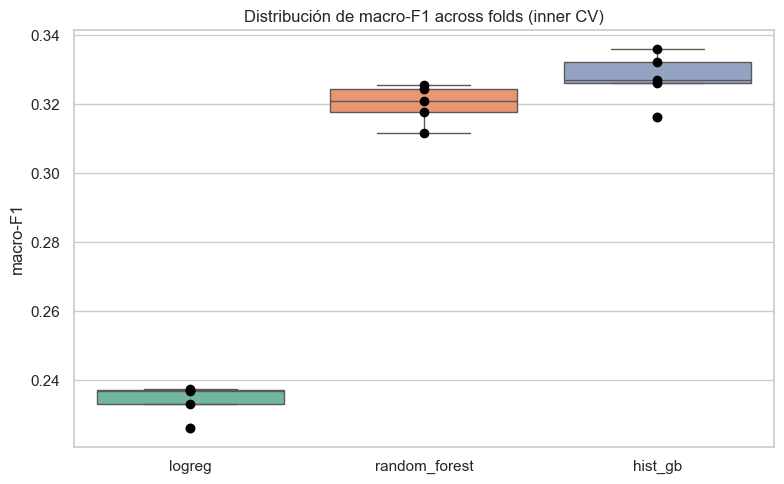

In [13]:
# Visualización: distribución de macro-F1 por modelo across folds.
mf1 = scores_df[scores_df["metric"] == "macro_f1"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=mf1, x="model", y="score", ax=ax, hue="model",
            palette="Set2", legend=False)
sns.stripplot(data=mf1, x="model", y="score", ax=ax, color="black",
              size=7, jitter=False)
ax.set_title("Distribución de macro-F1 across folds (inner CV)")
ax.set_ylabel("macro-F1")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / "cv_macro_f1_by_model.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Comparación estadística entre modelos

Las medias por modelo de la sección 5 sugieren que `random_forest` y `hist_gb` están **muy cerca** (diferencia ~0.008 en macro-F1 vs std ~0.005), mientras que `logreg` queda claramente atrás. Para decidir si las diferencias son estadísticamente significativas usamos:

1. **Paired t-test** sobre los 5 scores por fold (cada modelo entrenado en los mismos splits → pares emparejados).
2. **Wilcoxon signed-rank test** (no paramétrico, robusto a no-normalidad; sklearn no garantiza distribución normal de scores).
3. **Cohen's d** — tamaño del efecto estandarizado (no solo "es significativo" sino "qué tan grande es la diferencia").
4. **Corrección Bonferroni** — con 3 comparaciones pareadas (C(3,2) = 3), multiplicamos los p-values por 3 para controlar el error tipo I global.
5. **Bootstrap CI 95%** sobre los scores de cada modelo para visualizar incertidumbre.

Nivel de significancia: α = 0.05 (post-corrección).

In [14]:
from itertools import combinations

from scipy.stats import ttest_rel, wilcoxon

PRIMARY_METRIC = "macro_f1"
ALPHA = 0.05

# Extraer scores por modelo para la métrica primaria.
mf1_scores: dict[str, np.ndarray] = {
    name: scores_df[
        (scores_df["model"] == name) & (scores_df["metric"] == PRIMARY_METRIC)
    ]["score"].to_numpy()
    for name in MODELS
}

pairs = list(combinations(MODELS.keys(), 2))
n_tests = len(pairs)

rows = []
for a, b in pairs:
    sa, sb = mf1_scores[a], mf1_scores[b]
    diff = sa - sb

    t_stat, t_p = ttest_rel(sa, sb)
    w_stat, w_p = wilcoxon(sa, sb)

    # Cohen's d para muestras pareadas: media(diff) / std(diff).
    d_std = diff.std(ddof=1)
    cohens_d = float(diff.mean() / d_std) if d_std > 0 else float("inf")

    rows.append(
        {
            "A": a,
            "B": b,
            "mean(A) − mean(B)": sa.mean() - sb.mean(),
            "t_stat": t_stat,
            "t_p_raw": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p_raw": w_p,
            "cohens_d": cohens_d,
        }
    )

pair_df = pd.DataFrame(rows)

# Bonferroni: multiplicar p-values por número de comparaciones, cap a 1.
pair_df["t_p_bonf"] = (pair_df["t_p_raw"] * n_tests).clip(upper=1.0)
pair_df["wilcoxon_p_bonf"] = (pair_df["wilcoxon_p_raw"] * n_tests).clip(upper=1.0)
pair_df["sig_t_bonf"] = pair_df["t_p_bonf"] < ALPHA
pair_df["sig_w_bonf"] = pair_df["wilcoxon_p_bonf"] < ALPHA

print(f"Comparaciones pareadas sobre {PRIMARY_METRIC}  "
      f"(n_tests = {n_tests}, α = {ALPHA} post-Bonferroni)\n")
pair_df.round(5)

Comparaciones pareadas sobre macro_f1  (n_tests = 3, α = 0.05 post-Bonferroni)



,A,B,mean(A) − mean(B),t_stat,t_p_raw,wilcoxon_stat,wilcoxon_p_raw,cohens_d,t_p_bonf,wilcoxon_p_bonf,sig_t_bonf,sig_w_bonf
0,logreg,random_forest,-0.08587,-22.87019,0.00002,0.0,0.0625,-10.22786,0.00006,0.1875,True,False
1,logreg,hist_gb,-0.09338,-24.43671,0.00002,0.0,0.0625,-10.92843,0.00005,0.1875,True,False
2,random_forest,hist_gb,-0.00751,-2.59214,0.06055,0.0,0.0625,-1.15924,0.18164,0.1875,False,False


In [15]:
# Bootstrap CI 95% para macro-F1 por modelo (10 000 resamples de los 5 scores).
rng = np.random.default_rng(RANDOM_STATE)
N_BOOT = 10_000

ci_rows = []
for name in MODELS:
    s = mf1_scores[name]
    boots = rng.choice(s, size=(N_BOOT, len(s)), replace=True).mean(axis=1)
    ci_rows.append(
        {
            "model": name,
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)),
            "ci_lo_95": float(np.percentile(boots, 2.5)),
            "ci_hi_95": float(np.percentile(boots, 97.5)),
        }
    )

ci_df = pd.DataFrame(ci_rows).set_index("model")
ci_df.round(4)

,mean,std,ci_lo_95,ci_hi_95
model,,,,
logreg,0.2342,0.0048,0.2299,0.2372
random_forest,0.3200,0.0056,0.3154,0.3241
hist_gb,0.3276,0.0074,0.3214,0.3327


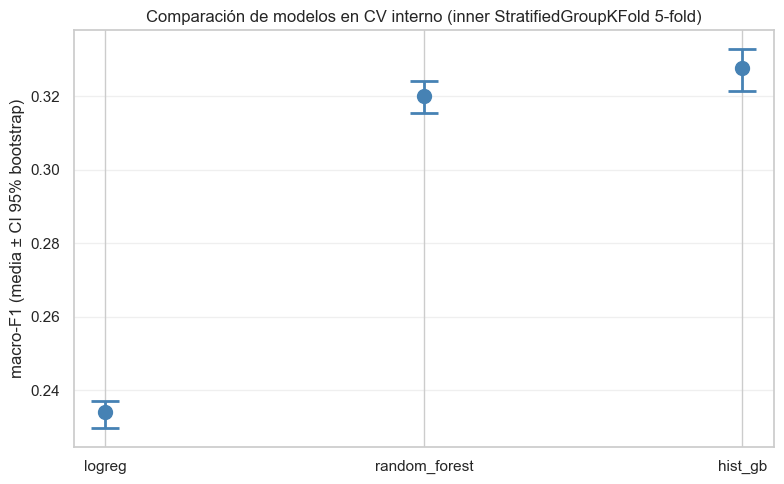

In [16]:
# Visualización: macro-F1 media con CI 95% por bootstrap.
fig, ax = plt.subplots(figsize=(8, 5))
models_order = list(MODELS.keys())
xs = np.arange(len(models_order))
means = [ci_df.loc[m, "mean"] for m in models_order]
errs_lo = [ci_df.loc[m, "mean"] - ci_df.loc[m, "ci_lo_95"] for m in models_order]
errs_hi = [ci_df.loc[m, "ci_hi_95"] - ci_df.loc[m, "mean"] for m in models_order]

ax.errorbar(
    xs, means, yerr=[errs_lo, errs_hi],
    fmt="o", capsize=10, capthick=2, markersize=10, linewidth=2,
    color="steelblue",
)
ax.set_xticks(xs)
ax.set_xticklabels(models_order)
ax.set_ylabel("macro-F1 (media ± CI 95% bootstrap)")
ax.set_title("Comparación de modelos en CV interno (inner StratifiedGroupKFold 5-fold)")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / "cv_macro_f1_with_ci.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. Evaluación final en test holdout

Procedimiento:

1. **Seleccionar el modelo ganador** del CV interno usando macro-F1 medio (con desempates por tiempo de entrenamiento o simplicidad si la diferencia no es estadísticamente significativa).
2. **Re-entrenar** el modelo seleccionado sobre el **train completo** (80%, 71 657 muestras).
3. **Evaluar una sola vez** sobre el **test holdout** (20%, 17 914 muestras) — este conjunto no fue tocado por ningún paso de CV o tuning.
4. Reportar métricas globales + per-clase + matriz de confusión.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    top_k_accuracy_score,
)

# Modelo ganador: mayor macro-F1 medio en CV. Si la diferencia con el segundo
# no es significativa post-Bonferroni, podríamos elegir el más simple/rápido,
# pero documentamos la regla y aplicamos la primaria.
best_model_name = max(mf1_scores, key=lambda n: mf1_scores[n].mean())
print(f"Modelo ganador por macro-F1 medio en CV: {best_model_name}")
print(f"  CV macro-F1: {mf1_scores[best_model_name].mean():.4f} "
      f"± {mf1_scores[best_model_name].std(ddof=1):.4f}")

# Re-entrenar sobre todo el train (80%).
best_pipe = MODELS[best_model_name]
print(f"\nEntrenando {best_model_name} sobre el train completo ({len(X_train):,} filas)...")
t0 = time.time()
best_pipe.fit(X_train, y_train)
print(f"  Tiempo: {time.time() - t0:.1f}s")

Modelo ganador por macro-F1 medio en CV: hist_gb
  CV macro-F1: 0.3276 ± 0.0074

Entrenando hist_gb sobre el train completo (71,657 filas)...


  Tiempo: 13.8s


In [18]:
# Evaluar UNA SOLA VEZ sobre el test holdout.
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)
classes_ = best_pipe.classes_

holdout_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "macro_f1": f1_score(y_test, y_pred, average="macro"),
    "top3_accuracy": top_k_accuracy_score(
        y_test, y_proba, k=3, labels=classes_
    ),
}

print(f"=== Test holdout final ({best_model_name}) ===")
for m, v in holdout_metrics.items():
    print(f"  {m:<18s} = {v:.4f}")

# Comparar con la media de CV para detectar overfit al CV/train.
print("\nDelta vs. CV (test - cv_mean):")
cv_means = {
    "accuracy": scores_df[(scores_df["model"] == best_model_name)
                          & (scores_df["metric"] == "accuracy")]["score"].mean(),
    "balanced_accuracy": scores_df[(scores_df["model"] == best_model_name)
                                   & (scores_df["metric"] == "balanced_accuracy")]["score"].mean(),
    "macro_f1": scores_df[(scores_df["model"] == best_model_name)
                          & (scores_df["metric"] == "macro_f1")]["score"].mean(),
    "top3_accuracy": scores_df[(scores_df["model"] == best_model_name)
                               & (scores_df["metric"] == "top3_accuracy")]["score"].mean(),
}
for m in holdout_metrics:
    delta = holdout_metrics[m] - cv_means[m]
    print(f"  {m:<18s}  test={holdout_metrics[m]:.4f}  "
          f"cv_mean={cv_means[m]:.4f}  Δ={delta:+.4f}")

=== Test holdout final (hist_gb) ===
  accuracy           = 0.4334
  balanced_accuracy  = 0.3317
  macro_f1           = 0.3392
  top3_accuracy      = 0.6915

Delta vs. CV (test - cv_mean):
  accuracy            test=0.4334  cv_mean=0.4263  Δ=+0.0071
  balanced_accuracy   test=0.3317  cv_mean=0.3266  Δ=+0.0051
  macro_f1            test=0.3392  cv_mean=0.3276  Δ=+0.0117
  top3_accuracy       test=0.6915  cv_mean=0.6902  Δ=+0.0013


In [19]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

     ambient      0.512     0.555     0.532       960
   asian-pop      0.371     0.381     0.376      1254
   classical      0.477     0.349     0.403       501
  electronic      0.547     0.715     0.620      2978
        folk      0.382     0.444     0.411      1423
     hip-hop      0.195     0.049     0.079       447
        jazz      0.571     0.117     0.194       103
 kids-comedy      0.539     0.469     0.501       969
       latin      0.428     0.536     0.476      1835
       metal      0.604     0.603     0.604      1485
       other      0.308     0.150     0.201       294
         pop      0.219     0.074     0.111       713
      reggae      0.244     0.118     0.159       575
        rock      0.304     0.371     0.334      1932
   soul-funk      0.262     0.086     0.129       690
       world      0.305     0.290     0.297      1755

    accuracy                          0.433     17914
   macro avg      0.392   

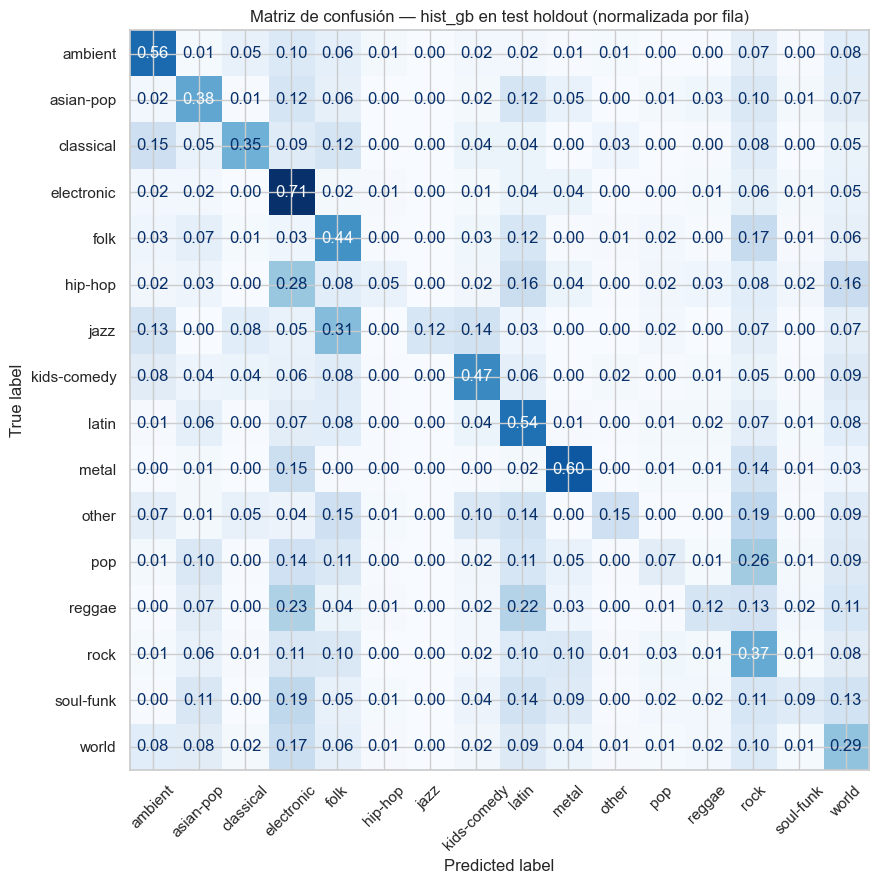

In [20]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=labels_sorted).plot(
    ax=ax, xticks_rotation=45, values_format=".2f", cmap="Blues", colorbar=False
)
ax.set_title(f"Matriz de confusión — {best_model_name} en test holdout (normalizada por fila)")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / f"confusion_matrix_{best_model_name}_holdout.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusiones

*Pendiente (Slice 6)* — redactar hallazgos, comparar con E1 corregido, definir modelo para E3.